In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

df = np.load("C:/DCU_final_year_project/kmeans_ready/ItoQUVcorrected_CBJTML_kmeans_ready_stokes_v.npy")

In [11]:
df.shape
#test = df.reshape(182, 2555*900)


(182, 2555, 900)

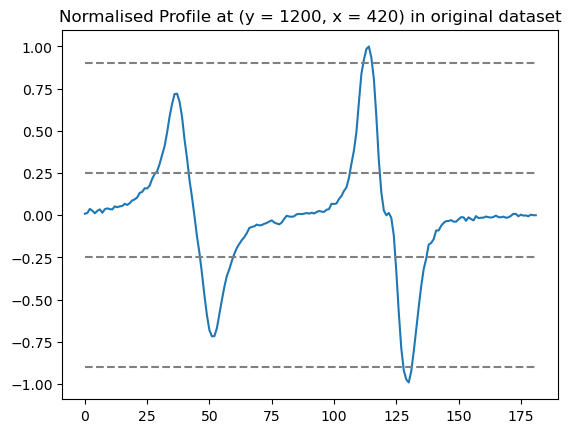

In [22]:
y_test, x_test = 1200, 420
wavelengths = np.linspace(0, 181, num = 182)

#plt.plot(wavelengths, sample_plot, label='Input at [y = ' + str(y_test) + ', x = ' + str(x_test) + ']')
plt.plot(wavelengths, df[:, y_test, x_test])
plt.title(f"Normalised Profile at (y = {y_test}, x = {x_test}) in original dataset")
plt.hlines(0.9, 0, 181, linestyle = '--', color = 'gray')
plt.hlines(0.25, 0, 181, linestyle = '--', color = 'gray')
plt.hlines(-0.25, 0, 181, linestyle = '--', color = 'gray')
plt.hlines(-0.9, 0, 181, linestyle = '--', color = 'gray')
plt.show()

In [3]:
# Classify K-means clusters

print(df[0])

[[-5.66384504e-04  1.89907202e-01  3.99586639e-01 ...  1.82676387e-01
  -3.10296764e-01 -2.20133699e-01]
 [ 2.44396223e-02  3.05531820e-01  5.64865895e-02 ... -2.48759749e-01
  -8.42620578e-02 -6.41166414e-02]
 [-1.30579066e-01 -3.48207988e-02  3.76479587e-02 ... -2.15593733e-01
  -2.87031398e-01  1.36985913e-01]
 ...
 [-1.80670587e-01  3.66174984e-02  4.42681237e-02 ...  0.00000000e+00
   0.00000000e+00  0.00000000e+00]
 [-3.65901921e-01  4.19761296e-01 -5.50173017e-01 ...  0.00000000e+00
   0.00000000e+00  0.00000000e+00]
 [ 6.05121673e-01 -3.37697635e-01  1.33597589e-01 ...  0.00000000e+00
   0.00000000e+00  0.00000000e+00]]


In [3]:
region_of_interest = df[:, 700:1700, :]
region_of_interest.shape

(182, 1000, 900)

In [4]:
arr = region_of_interest
reshaped_array = np.moveaxis(arr, 0, -1).reshape(-1, 182)

reshaped_array.shape

(900000, 182)

In [6]:


kmeans = KMeans(n_clusters=35, random_state=0).fit(reshaped_array)
kmeans.labels_
#kmeans.fit
help_me = kmeans.cluster_centers_





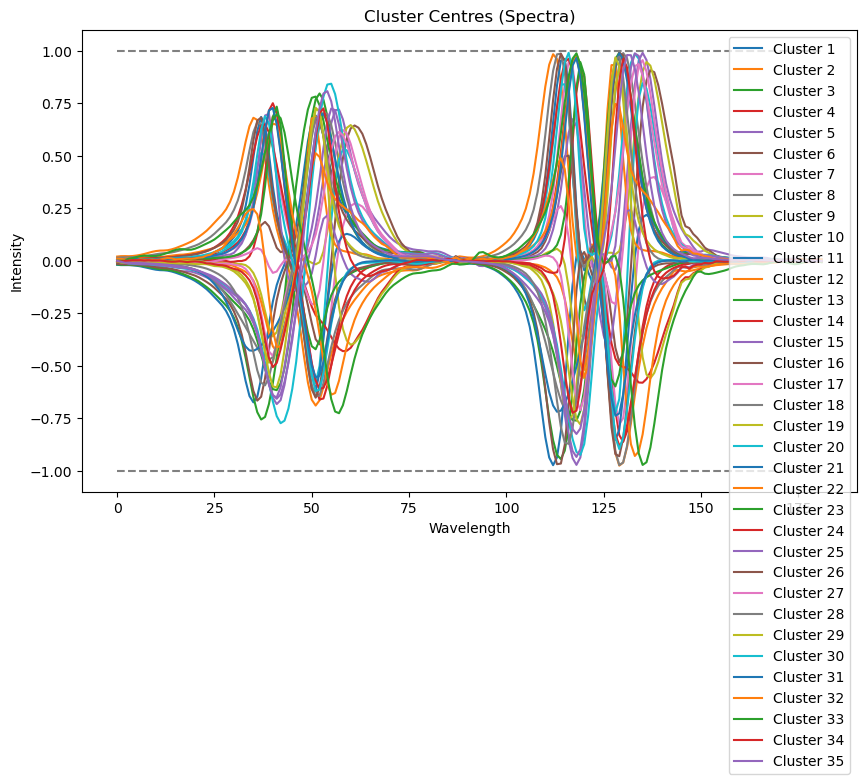

In [7]:
wavelength_axis = np.arange(182)

plt.figure(figsize=(10, 6))
for i in range(help_me.shape[0]):
    plt.plot(wavelength_axis, help_me[i], label=f"Cluster {i+1}")
plt.hlines(1.0, 0, 181, linestyles = '--', color = 'gray')
plt.hlines(-1.0, 0, 181, linestyles = '--', color = 'gray')
plt.title("Cluster Centres (Spectra)")
plt.xlabel("Wavelength")
plt.ylabel("Intensity")
plt.legend()
plt.show()


In [8]:
labels = kmeans.labels_

labels_image = labels.reshape(1000, 900)
labels_image.shape

print(labels_image)

[[22 22 22 ...  3  3  3]
 [22 22 22 ...  3  3  3]
 [22 22 22 ...  3  3  3]
 ...
 [11 11 11 ... 30 30 22]
 [11 11 11 ... 30 14 14]
 [11 11 11 ... 30 14 14]]


In [13]:
print(len(labels))
def cluster_rate(arr, n):
    cluster_arr = []
    for i in arr:
        if i == n:
            cluster_arr.append(i)
    cluster_count = len(cluster_arr)
    
    cluster_rate_raw = cluster_count / len(arr)
    cluster_rate_percentage = cluster_rate_raw * 100
    
    return(cluster_rate_percentage)

print(cluster_rate(labels, 3))

aeiou = 0
bleh = 0
while aeiou < 35:
    bleh = bleh + cluster_rate(labels, aeiou)
    aeiou = aeiou + 1

print(bleh)

900000
4.4415555555555555
100.0


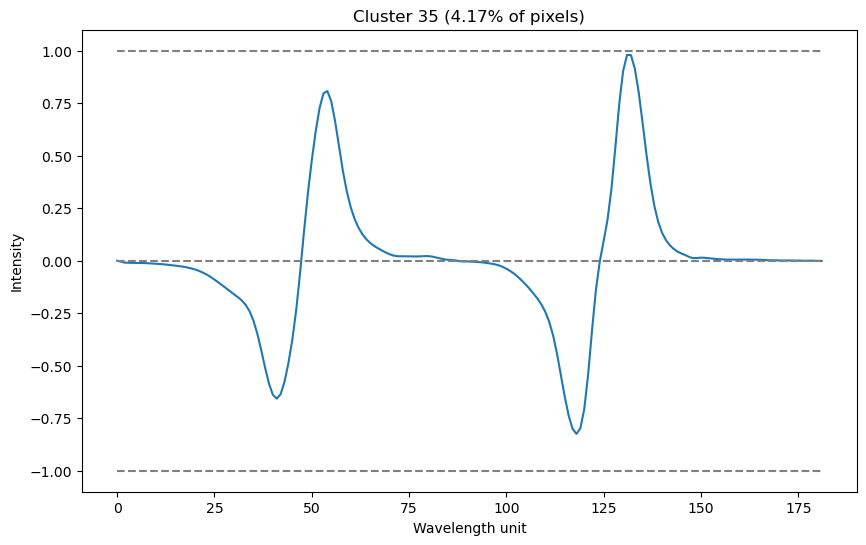

In [49]:
wavelength_axis = np.arange(182)


plt.figure(figsize=(10, 6))
i = 20

percentage_raw = cluster_rate(labels, i)
percentage_two_decimals = round(percentage_raw, 2)

plt.plot(wavelength_axis, help_me[i])

plt.hlines(1.0, 0, 181, linestyles = '--', color = 'gray')
plt.hlines(-1.0, 0, 181, linestyles = '--', color = 'gray')
plt.hlines(0, 0, 181, linestyles = '--', color = 'gray')

plt.title(f"Cluster {i + 1} ({percentage_two_decimals}% of pixels)")
plt.xlabel("Wavelength unit")
plt.ylabel("Intensity")
plt.savefig(f'C:/DCU_final_year_project/kmeans_figs/kmeans_indiv_spectra_again/kmeanscluster_{i+1}.png')
plt.show()



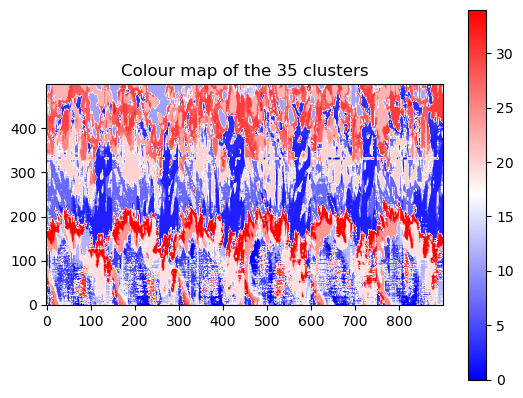

In [52]:
plt.imshow(labels_image[500:2000, :], origin = 'lower', cmap = 'bwr')
plt.title(f"Colour map of the 35 clusters")
plt.colorbar()
plt.show()


In [1]:
def highlight_cluster(arr, n):
    highlighted_cluster = []
    for i in arr:
        if i == n:
            highlighted_cluster.append(i)
        else:
            highlighted_cluster.append(-1)
    return np.array(highlighted_cluster)


In [2]:
selected_cluster = 34

percentage_raw = cluster_rate(labels, selected_cluster)
percentage_two_decimals = round(percentage_raw, 2)

highlighted_labels = highlight_cluster(labels, selected_cluster)

highlighted_image = highlighted_labels.reshape(1000, 900)
plt.title(f"Class {selected_cluster + 1} locations ({percentage_two_decimals}% of pixels)")
plt.imshow(highlighted_image[:,:], origin = 'lower', cmap = 'gray')
plt.savefig(f'C:/DCU_final_year_project/kmeans_figs/cluster_maps_again/cluster_{selected_cluster+1}_map.png')
plt.show()

NameError: name 'cluster_rate' is not defined

In [100]:
np.save('C:/DCU_final_year_project/kmeans_figs/kmeans_cluster_centers_sunspot_filtered_again', help_me)

In [101]:
np.save('C:/DCU_final_year_project/prepared_data/sunspot_region_stokes_v_again', region_of_interest)